# Heteroscedastic mixed-variable BO — 3-method comparison

| study | model of the 5 categories | shares? |
|---|---|---|
| `study_v2` (LVGP) | one latent-variable GP | yes |
| `study_v2_gp` | 5 independent GPs | **no** |
| `study_v2_cat` (Method C) | one MixedSingleTaskGP + CategoricalKernel | yes |

**Kernel: ml_gp_env.**

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys; sys.path.insert(0, os.path.abspath("study_v2_cat"))
%matplotlib inline
import numpy as np, pandas as pd
from utils import (StudyResults, compare_studies, compare_studies_multi,
                   compare_summary_heatmaps, problem)
from utils.results import _metric_trajectories, _cfg_param

lvgp = StudyResults.load("study_v2/results"); gp = StudyResults.load("study_v2_gp/results")
cat  = StudyResults.load("study_v2_cat/results")
studies = [(lvgp, "LVGP"), (gp, "Per-category GP"), (cat, "Categorical GP")]
print({lab: len(s.runs) for s, lab in studies}, "runs | f* =", round(problem.ground_truth_min(),4))

{'LVGP': 1080, 'Per-category GP': 1080, 'Categorical GP': 1080} runs | f* = 0.4651


## The single toggle: `GROUND_TRUTH`
Drives **every** comparison below — convergence overlays *and* the summary heatmap use the same
definition of "best design", so they're consistent:
- **`True`** — lowest **TRUE** objective among all sampled points (`min_i f_true(x_i)`); never the noisy mean.
- **`False`** — lowest **NOISY** sample-mean (what BO would recommend); can read below f\* at small n_rep.

In [2]:
GROUND_TRUTH = True      # <-- flip to False for the noisy-mean version of every plot below

### Final value of the best design (table)

In [3]:
def final_value_table(studies, n_rep=10):
    metric = "true" if GROUND_TRUTH else "noisy"
    cols = {}
    for s, lab in studies:
        t = _metric_trajectories(s, metric, n_rep, as_regret=False)         # raw best VALUE
        cols[lab] = {problem.label(c[0], _cfg_param(c)): v[1][-1] for c, v in t.items()}
    order = [problem.label(a, p) for a, p in problem.CONFIG_ORDER]
    return pd.DataFrame(cols).reindex([o for o in order if o in pd.DataFrame(cols).index])

print(("f* = %.4f (all >= f*)" % problem.ground_truth_min()) if GROUND_TRUTH else "noisy values (can be < f*)")
final_value_table(studies, n_rep=10).round(4)

f* = 0.4651 (all >= f*)


,LVGP,Per-category GP,Categorical GP
LCB,0.5532,0.4824,0.5753
PI,1.5105,1.0282,0.6123
EI,0.5025,2.4193,0.5862
HAEI(γ=0.5),0.4678,0.5623,0.5664
HAEI(γ=1),0.4698,0.4822,0.5338
HAEI(γ=5),0.4739,0.4709,0.5113
ANPEI(β=0.2),1.2978,1.6305,1.5548
ANPEI(β=0.5),0.5193,2.2771,0.5159
ANPEI(β=0.8),0.4660,2.1074,0.5300
RAHBO(α=0.5),0.4672,0.4727,0.4962


### Convergence — REGRET (value − f*), log axis

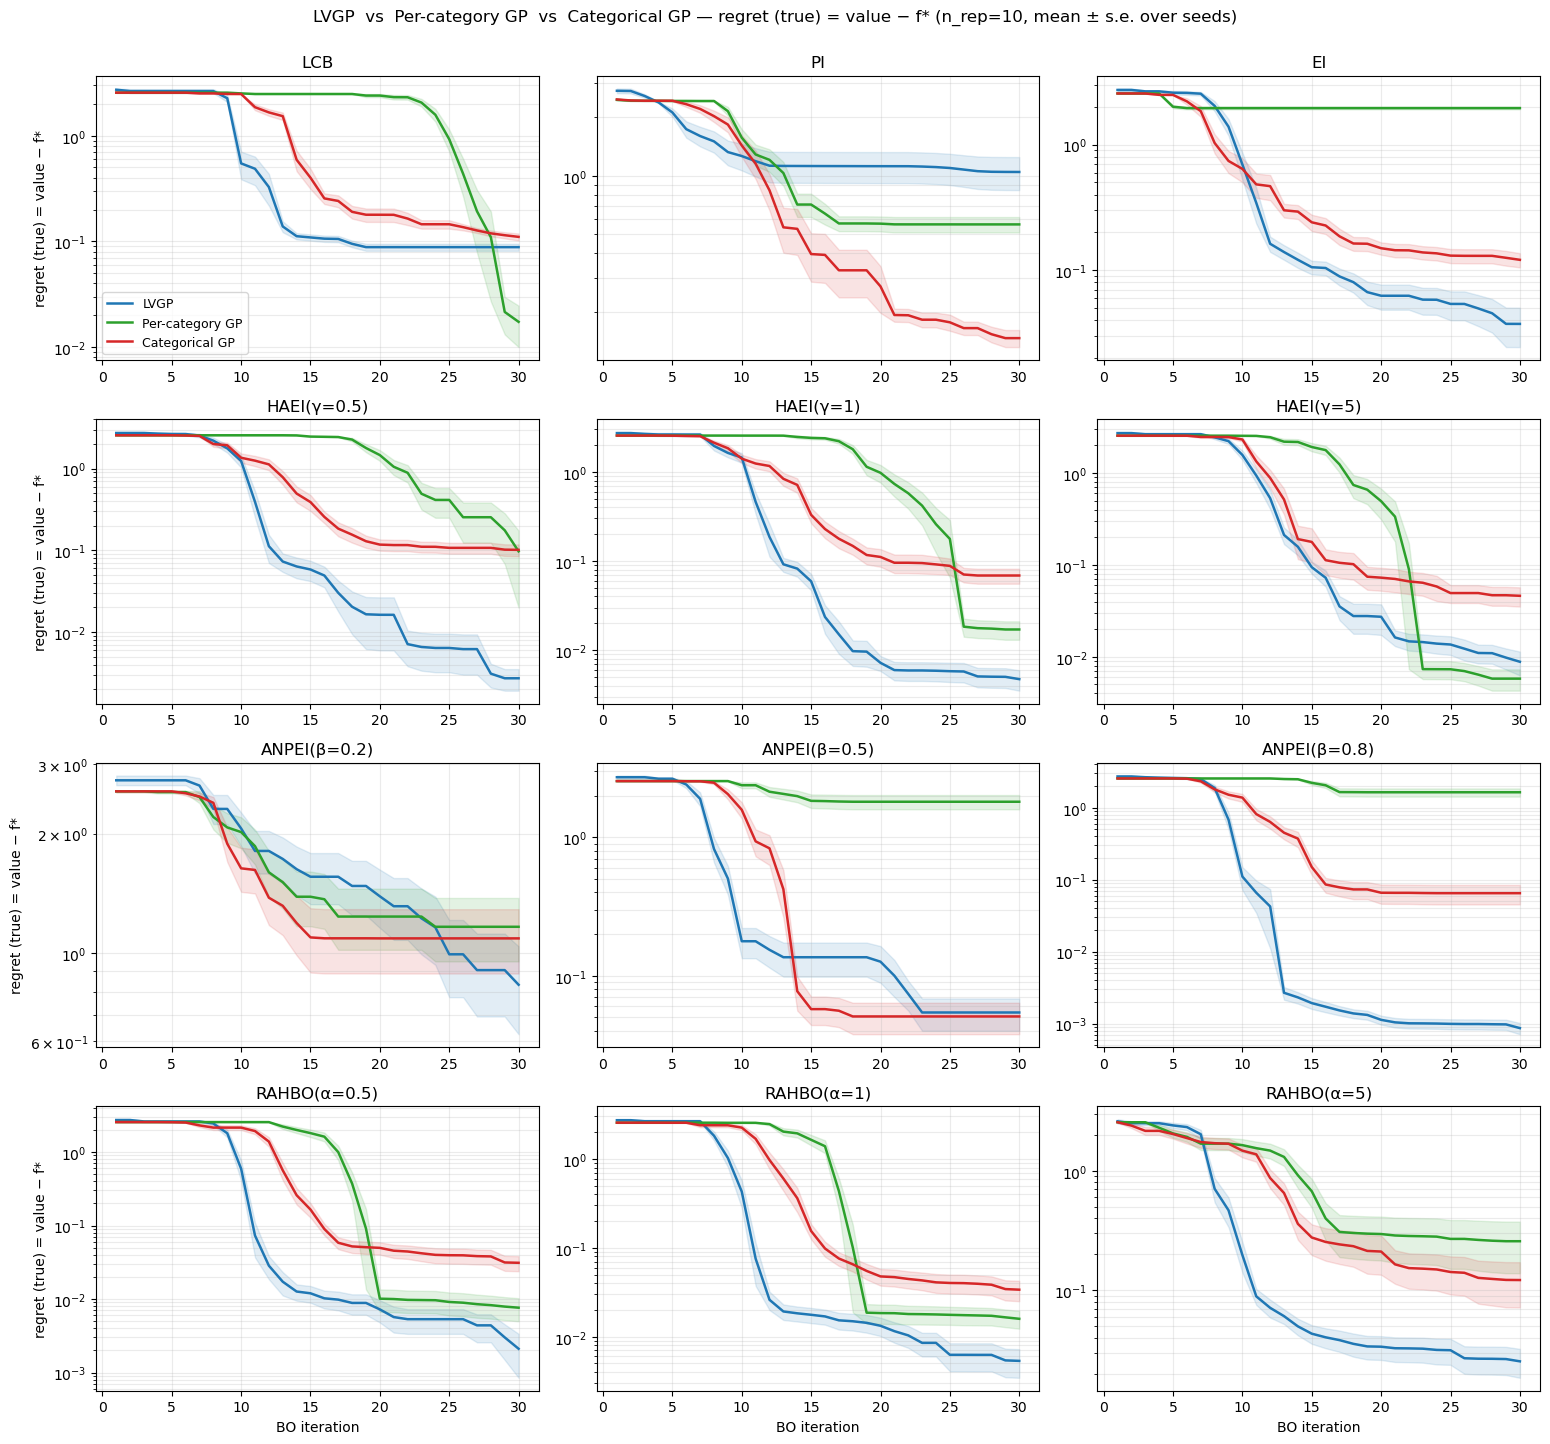

In [4]:
compare_studies_multi(studies, is_ground_truth=GROUND_TRUTH, n_rep=10)

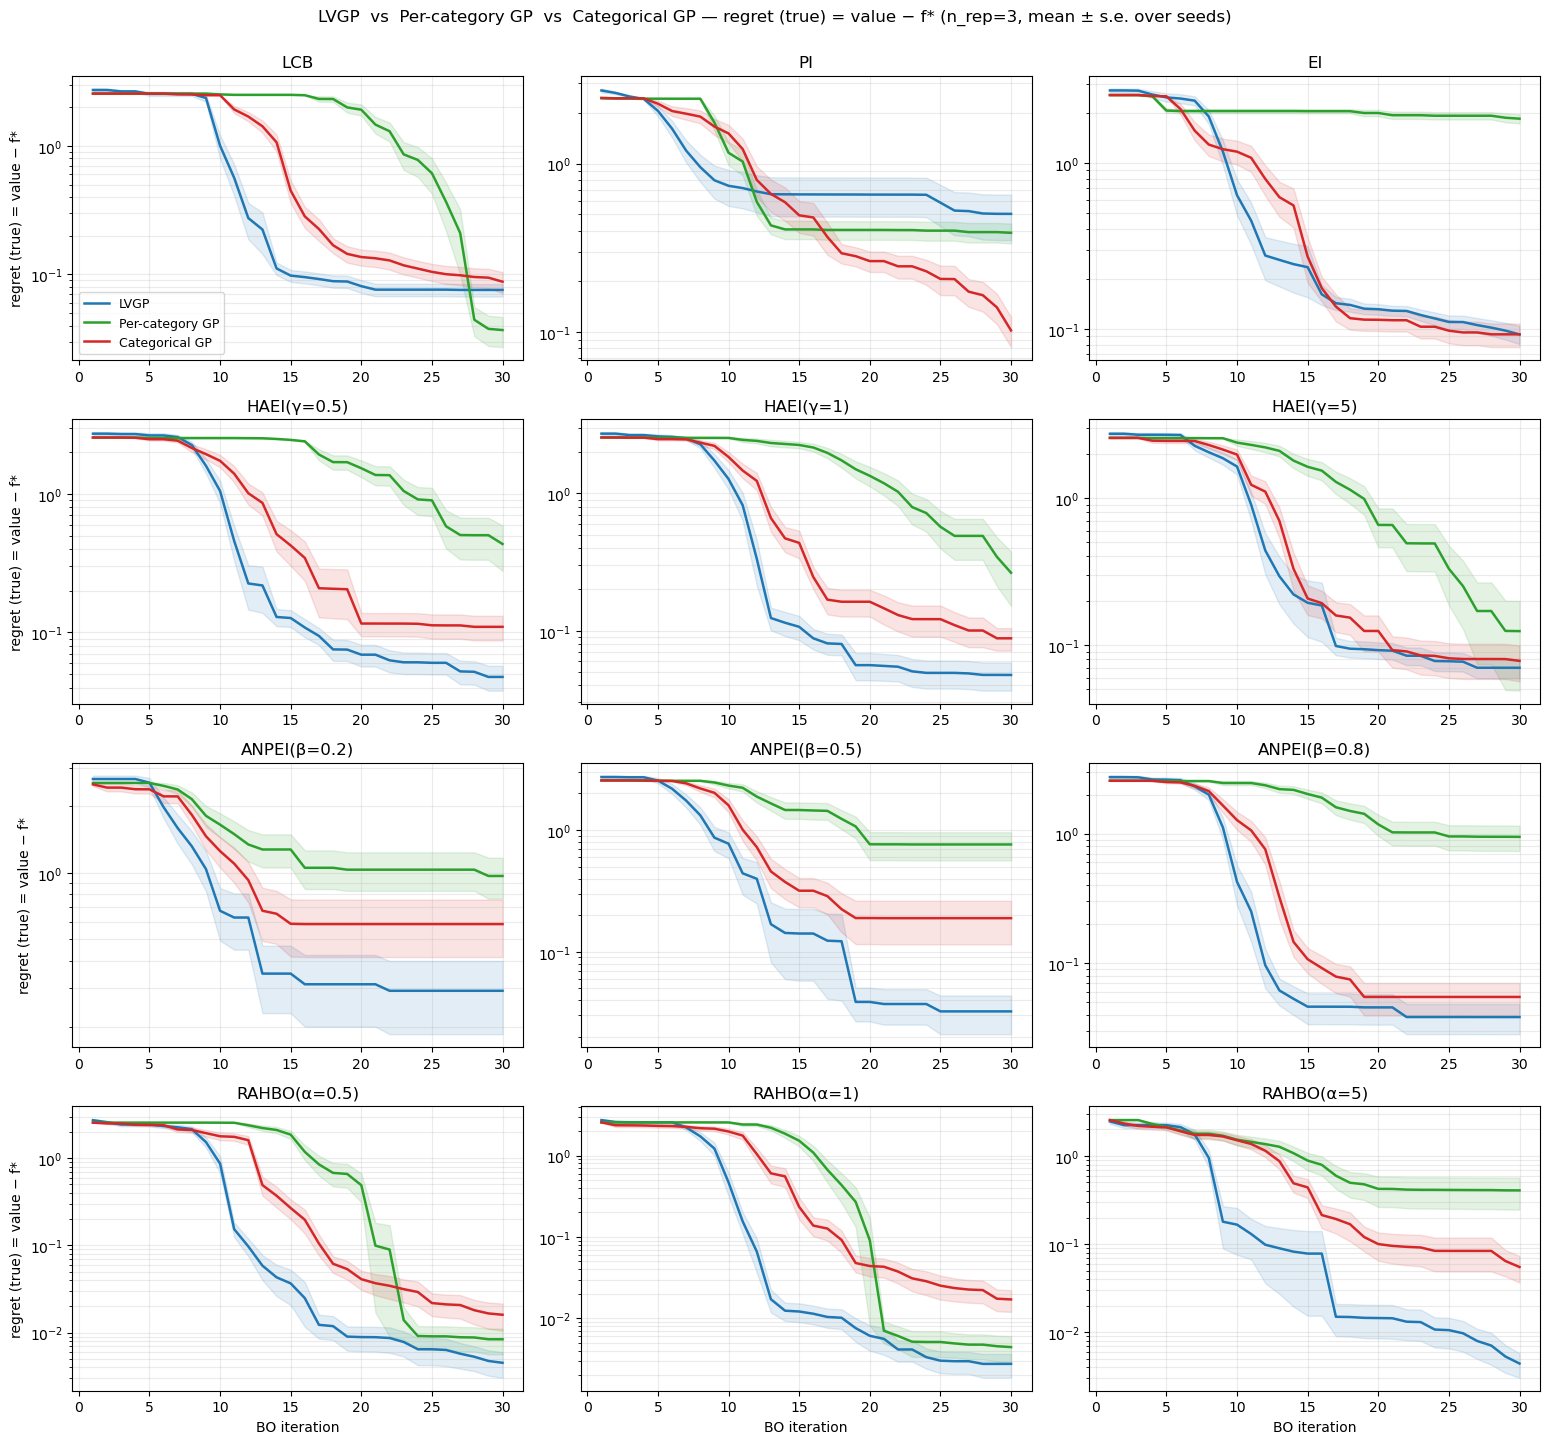

In [5]:
compare_studies_multi(studies, is_ground_truth=GROUND_TRUTH, n_rep=3)

### Convergence — VALUE (not regret), linear axis
`as_regret=False` plots the raw best objective **value** (converging to f\* ≈ 0.465 in ground-truth
mode) with a dotted f\* reference line, instead of the regret on a log axis.

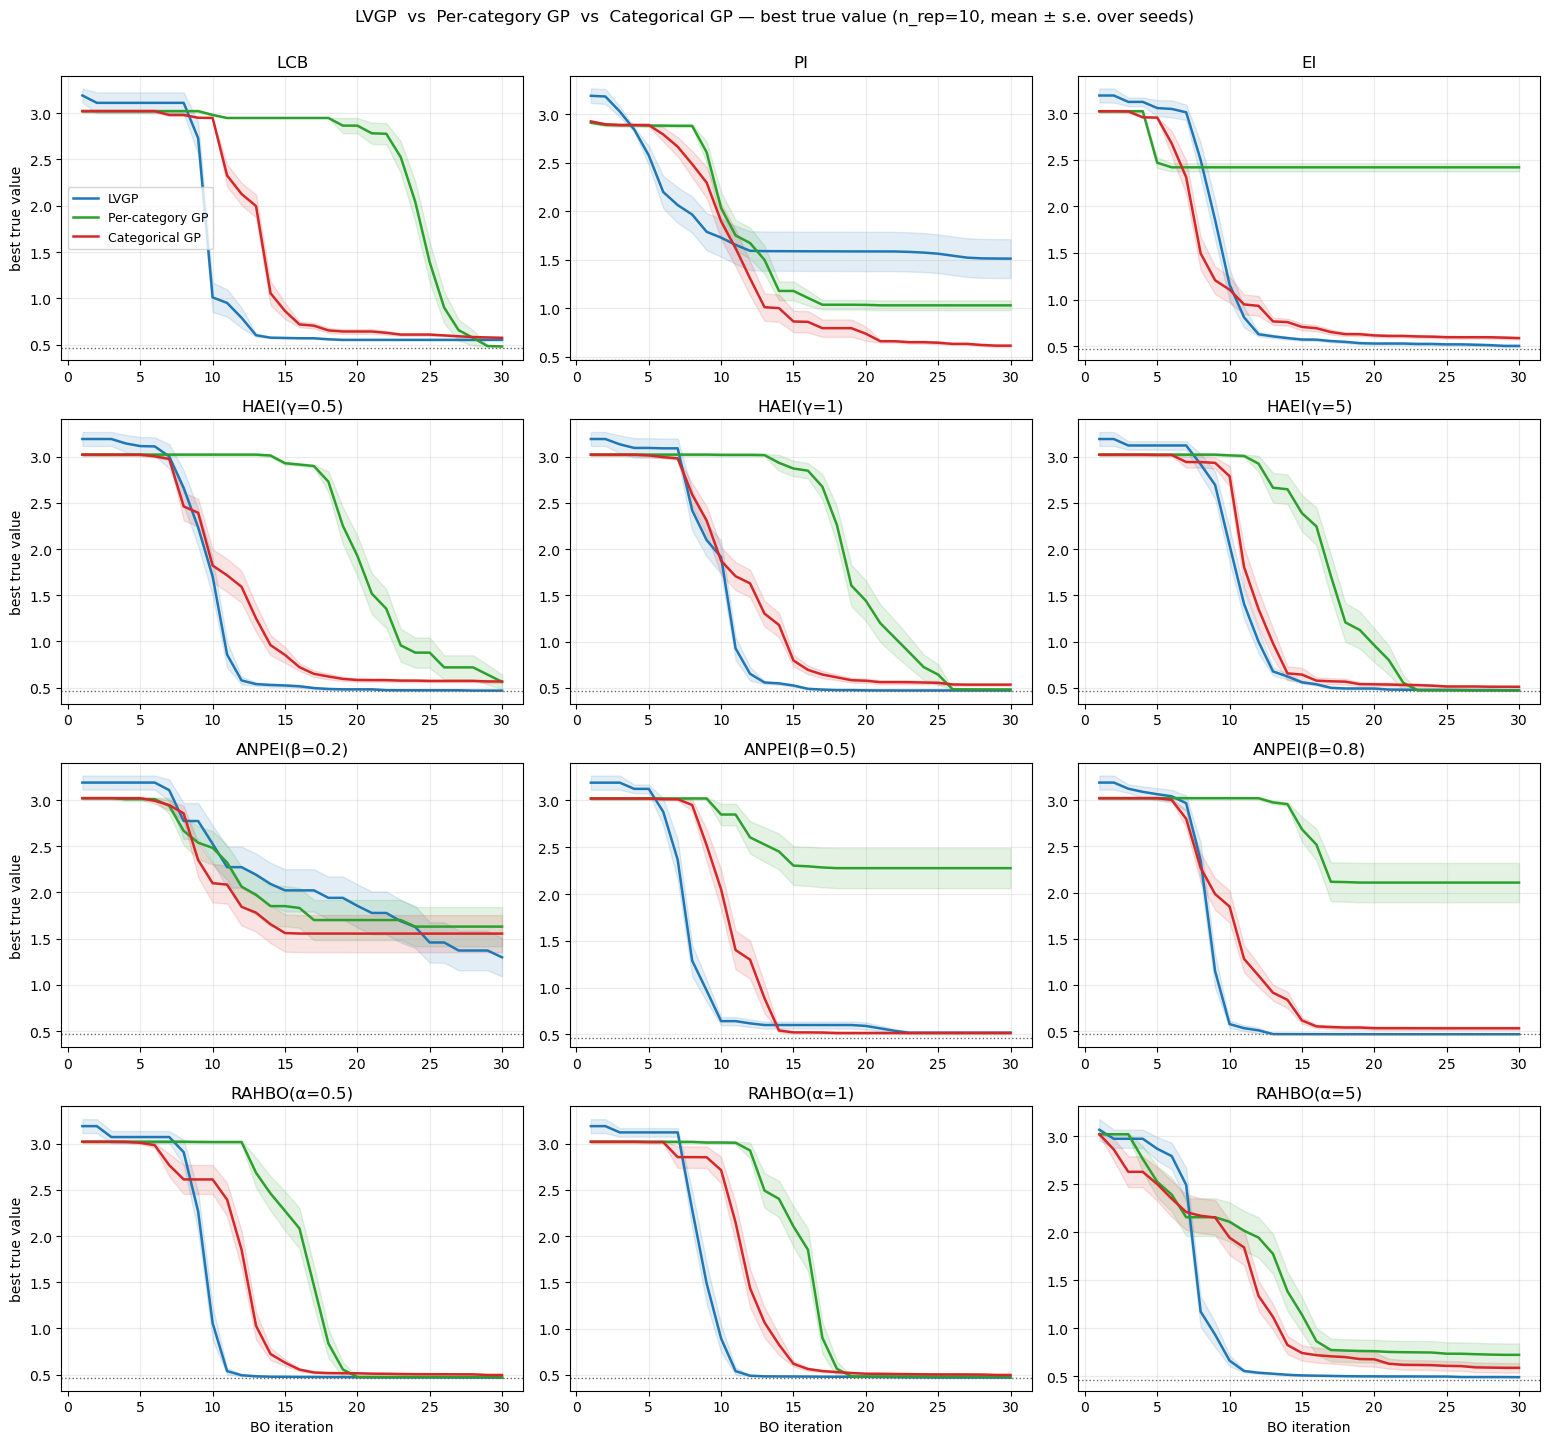

In [6]:
compare_studies_multi(studies, is_ground_truth=GROUND_TRUTH, as_regret=False, n_rep=10)

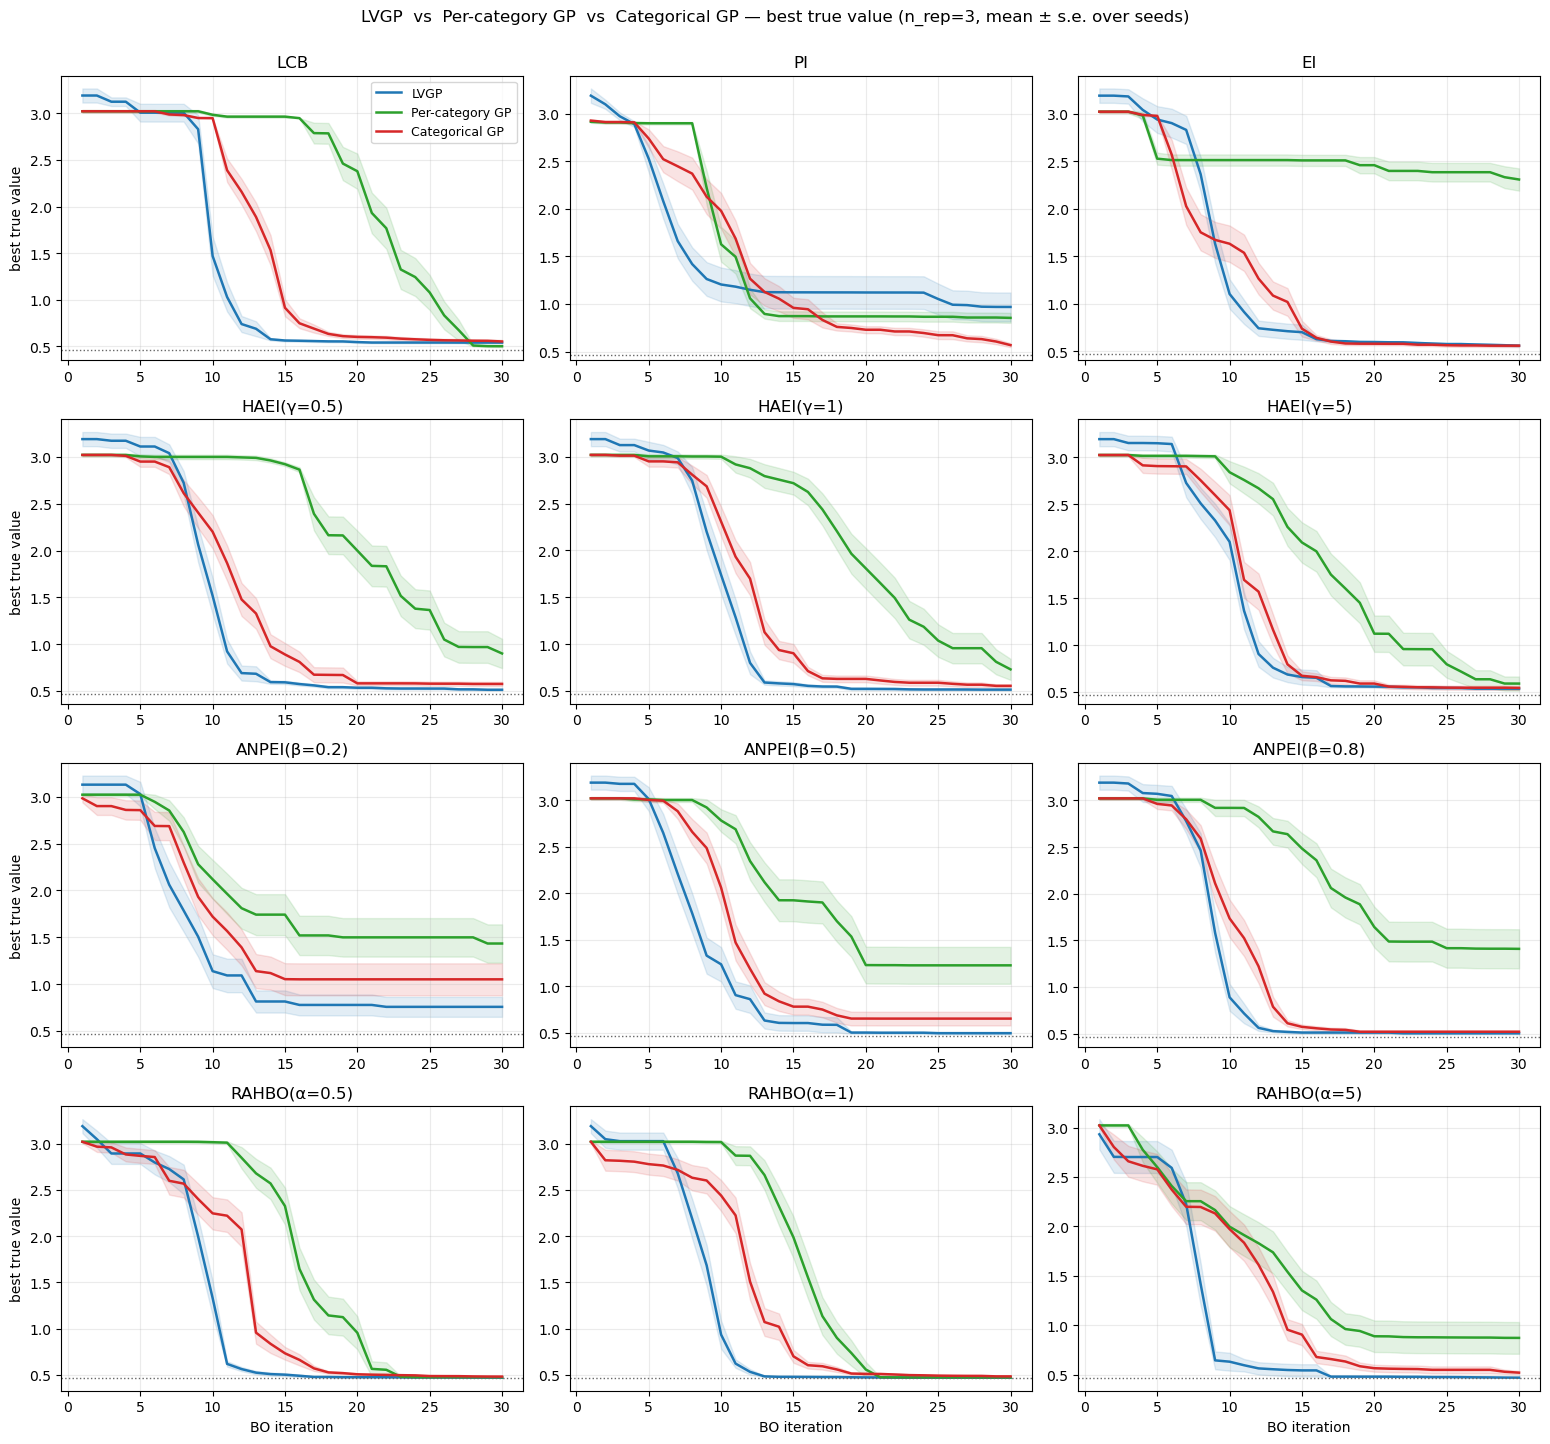

In [7]:
compare_studies_multi(studies, is_ground_truth=GROUND_TRUTH, as_regret=False, n_rep=3)

### Convergence of the noise variance σ² at the best design
How noisy is the design BO currently considers best, over iterations (lower = settling on more reliable, low-noise designs). Respects `GROUND_TRUTH`: `True` = TRUE σ²(x₁,level) at the best-by-true design; `False` = the n_rep sample variance at the best-by-noisy design.

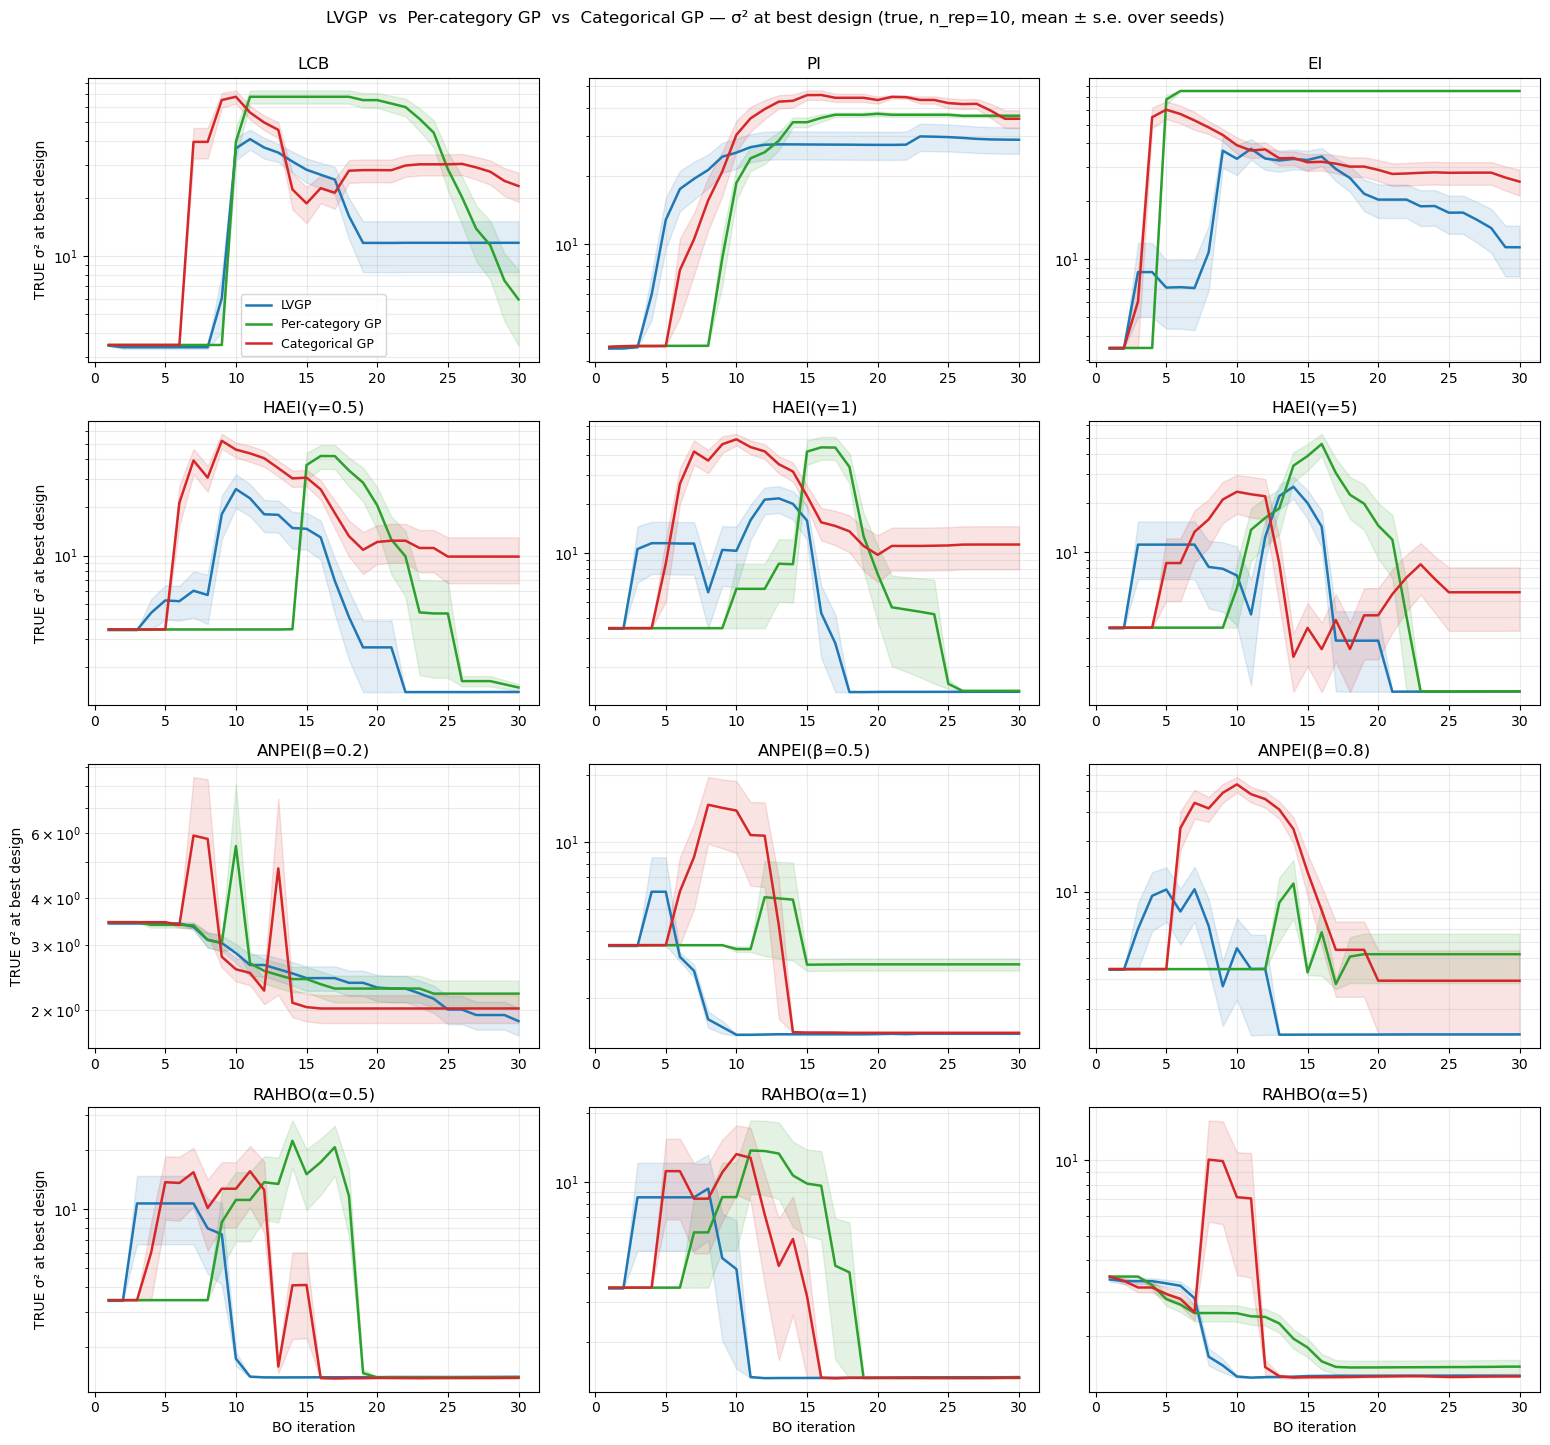

In [8]:
from utils import compare_variance_convergence
compare_variance_convergence(studies, is_ground_truth=GROUND_TRUTH, n_rep=10)

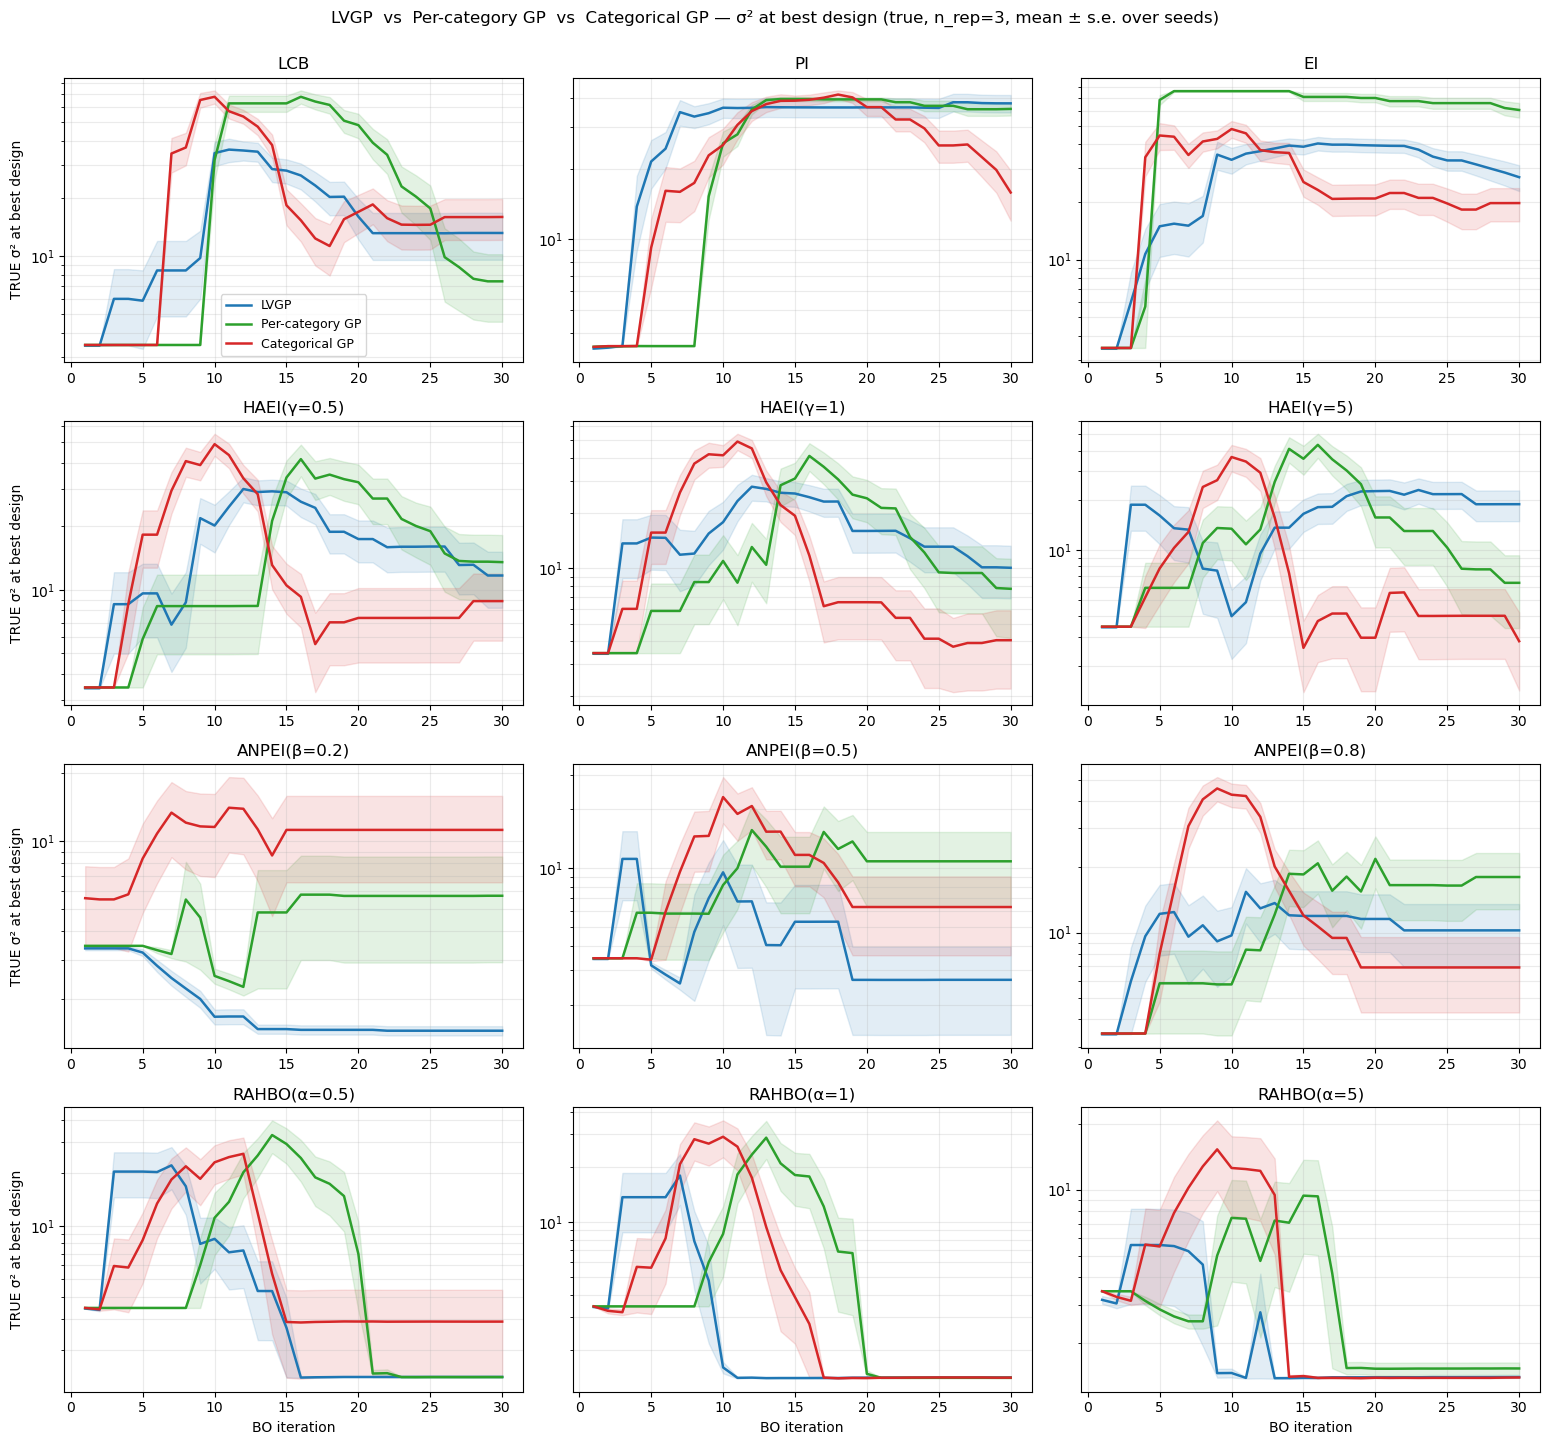

In [9]:
compare_variance_convergence(studies, is_ground_truth=GROUND_TRUTH, n_rep=3)

### Summary heatmaps — SAME selection, so final-iteration values match the table/convergence

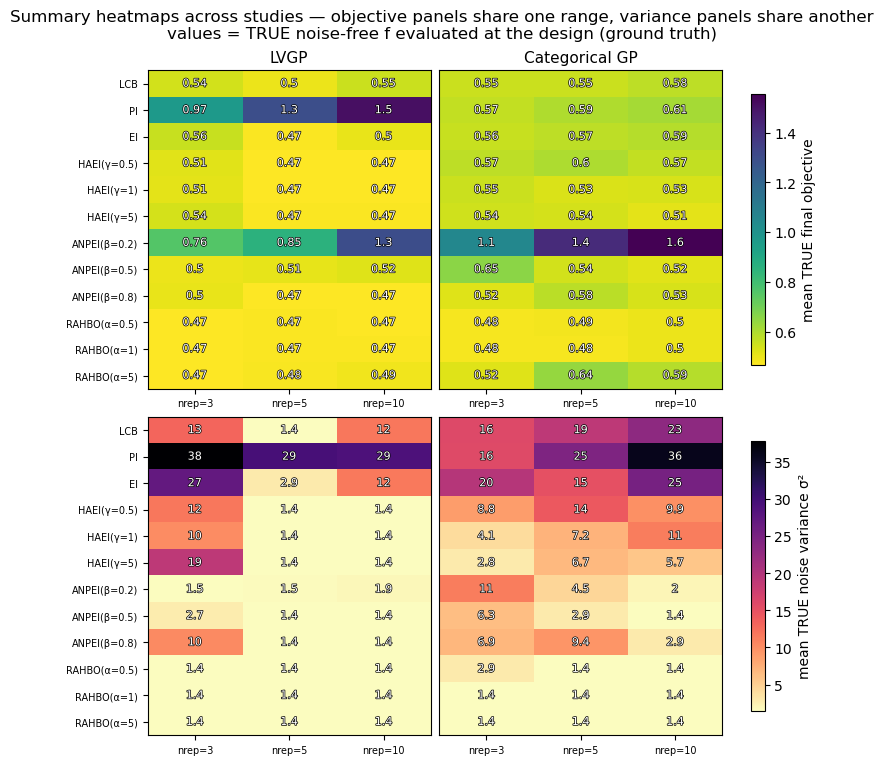

In [10]:
# heatmap column order: LVGP, Categorical (both share across categories), Per-category (no sharing) in the corner
heatmap_order = [(lvgp, "LVGP"), (cat, "Categorical GP")]#, (gp, "Per-category GP")]
compare_summary_heatmaps(heatmap_order, is_ground_truth=GROUND_TRUTH)

### Pairwise (categorical GP vs each)

In [11]:
# compare_studies(cat, gp,   is_ground_truth=GROUND_TRUTH, n_rep=10, labels=("Categorical GP", "Per-category GP"))

In [12]:
# compare_studies(cat, lvgp, is_ground_truth=GROUND_TRUTH, n_rep=10, labels=("Categorical GP", "LVGP"))

## Runtime comparison
Mean wall-clock seconds per BO run, grouped by acquisition, one bar per study (log y).
**Caveat:** LVGP is MATLAB and the GP studies are Python — different engines, so the absolute
magnitudes aren't a like-for-like speed test (~470 s vs ~30–40 s).

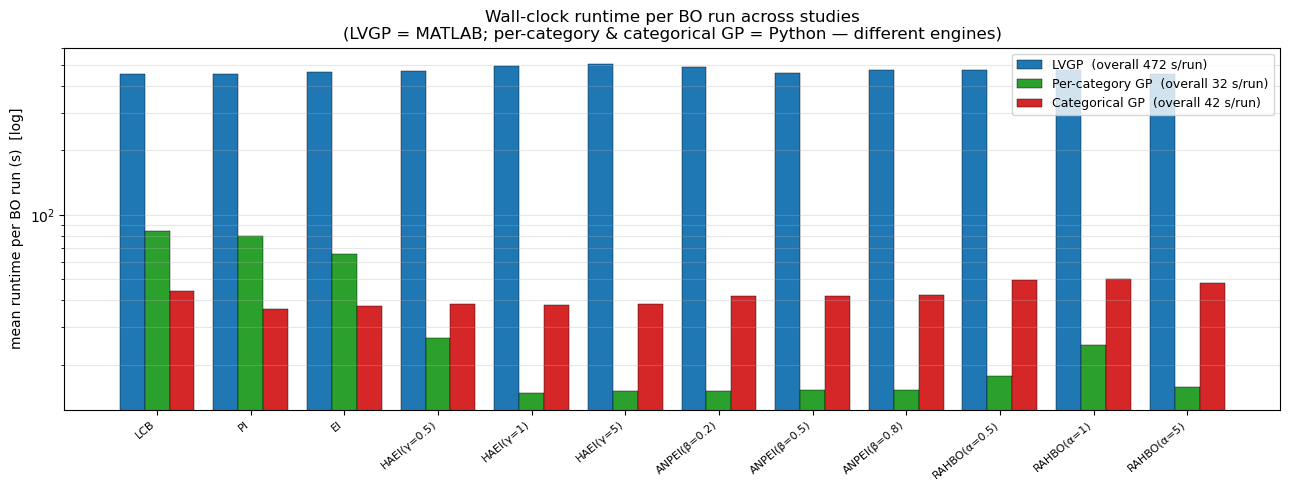

In [13]:
from utils import compare_runtime
compare_runtime(studies)

In [14]:
from utils import runtime_summary
rt_df = runtime_summary(studies, excel_path="results_all_studies/runtime_summary.xlsx")
rt_df.round(1)

Wall-clock runtime per BO run (seconds) and TOTAL compute per study (1080 runs each):

                 runs  mean_s  median_s  std_s  min_s  max_s  total_min  total_hr
study                                                                            
LVGP             1080   472.3     468.8   52.1  273.8  642.8     8501.4     141.7
Per-category GP  1080    32.5      15.9   26.8   12.5  101.6      584.3       9.7
Categorical GP   1080    42.3      39.8    9.1   29.4   74.0      761.9      12.7

Mean runtime relative to the fastest study (Per-category GP):
  LVGP                14.5x   (472 s/run, total 141.7 h)
  Per-category GP      1.0x   (32 s/run, total 9.7 h)
  Categorical GP       1.3x   (42 s/run, total 12.7 h)

Mean s/run by n_rep:
  LVGP               n_rep=3:   472s  n_rep=5:   477s  n_rep=10:   468s
  Per-category GP    n_rep=3:    35s  n_rep=5:    31s  n_rep=10:    31s
  Categorical GP     n_rep=3:    43s  n_rep=5:    43s  n_rep=10:    41s

wrote results_all_studies/runtime_s

,runs,mean_s,median_s,std_s,min_s,max_s,total_min,total_hr
study,,,,,,,,
LVGP,1080,472.3,468.8,52.1,273.8,642.8,8501.4,141.7
Per-category GP,1080,32.5,15.9,26.8,12.5,101.6,584.3,9.7
Categorical GP,1080,42.3,39.8,9.1,29.4,74.0,761.9,12.7
